In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

df = pd.read_csv('D:\BankLoanRisk-Intelligence\Dataset\loans_model_ready.csv')
print(df.shape)

TARGET = 'defaulted'

# Candidate features — deliberately excludes int_rate / grade / sub_grade (leakage, see above)
CONTINUOUS_FEATURES = [
    'loan_amnt', 'term_months', 'monthly_income', 'dti', 'bureau_score',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util', 'total_acc'
]
CATEGORICAL_FEATURES = ['purpose', 'emp_length', 'home_ownership']
# addr_state excluded from this pass: 50 categories is too sparse for clean WOE bins
# without grouping states into regions first — a good stretch task, not core scope here.

(150000, 21)


In [7]:
def woe_iv_continuous(df, feature, target=TARGET, n_bins=10):
    """Quantile-bin a continuous feature and compute WOE/IV per bin."""
    data = df[[feature, target]].dropna().copy()
    data['bin'], bin_edges = pd.qcut(data[feature], q=n_bins, duplicates='drop', retbins=True)
    summary = _woe_table(data, 'bin', target)
    summary['feature'] = feature
    return summary, bin_edges.tolist()

def woe_iv_categorical(df, feature, target=TARGET):
    """Compute WOE/IV per category for a categorical feature (each category = its own bin)."""
    data = df[[feature, target]].fillna('Unknown').copy()
    summary = _woe_table(data, feature, target)
    summary['feature'] = feature
    return summary, sorted(data[feature].unique().tolist())

def _woe_table(data, bin_col, target):
    grp = data.groupby(bin_col, observed=True)[target].agg(['count', 'sum'])
    grp.columns = ['total', 'bad']
    grp['good'] = grp['total'] - grp['bad']
    total_good = grp['good'].sum()
    total_bad = grp['bad'].sum()
    # small epsilon avoids divide-by-zero / log(0) for empty bins
    eps = 0.5
    grp['dist_good'] = (grp['good'] + eps) / (total_good + eps * len(grp))
    grp['dist_bad'] = (grp['bad'] + eps) / (total_bad + eps * len(grp))
    grp['woe'] = np.log(grp['dist_good'] / grp['dist_bad'])
    grp['iv_component'] = (grp['dist_good'] - grp['dist_bad']) * grp['woe']
    grp['bad_rate'] = grp['bad'] / grp['total']
    return grp.reset_index().rename(columns={bin_col: 'bin'})

In [8]:
woe_tables = {}
bin_definitions = {}
iv_summary = []

for feat in CONTINUOUS_FEATURES:
    table, edges = woe_iv_continuous(df, feat)
    woe_tables[feat] = table
    bin_definitions[feat] = {'type': 'continuous', 'edges': edges}
    iv_summary.append({'feature': feat, 'iv': table['iv_component'].sum(), 'n_bins': len(table)})

for feat in CATEGORICAL_FEATURES:
    table, categories = woe_iv_categorical(df, feat)
    woe_tables[feat] = table
    bin_definitions[feat] = {'type': 'categorical', 'categories': categories}
    iv_summary.append({'feature': feat, 'iv': table['iv_component'].sum(), 'n_bins': len(table)})

iv_df = pd.DataFrame(iv_summary).sort_values('iv', ascending=False).reset_index(drop=True)
iv_df['strength'] = pd.cut(
    iv_df['iv'],
    bins=[-1, 0.02, 0.1, 0.3, 0.5, np.inf],
    labels=['Not useful', 'Weak', 'Medium', 'Strong', 'Suspiciously strong — check leakage']
)
iv_df

,feature,iv,n_bins,strength
0,bureau_score,0.132523,10,Medium
1,dti,0.075294,10,Weak
2,home_ownership,0.044145,4,Weak
3,loan_amnt,0.034818,10,Weak
4,revol_util,0.034296,10,Weak
5,monthly_income,0.030045,10,Weak
6,inq_last_6mths,0.025086,3,Weak
7,purpose,0.020753,13,Weak
8,emp_length,0.013671,12,Not useful
9,open_acc,0.003351,10,Not useful


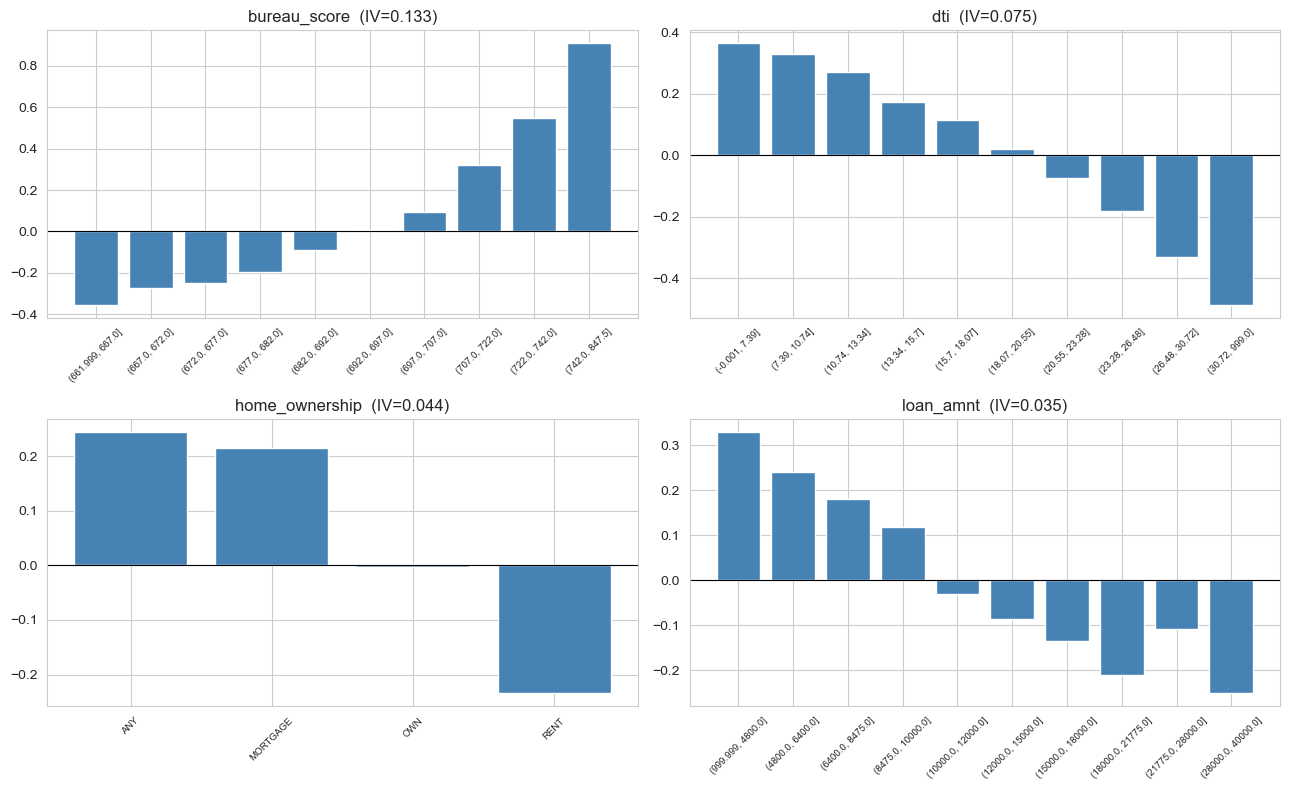

In [9]:
top_features = iv_df.head(4)['feature'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat in zip(axes.flat, top_features):
    table = woe_tables[feat].copy()
    table['bin_label'] = table['bin'].astype(str)
    ax.bar(table['bin_label'], table['woe'], color='steelblue')
    ax.set_title(f"{feat}  (IV={iv_df.loc[iv_df['feature']==feat, 'iv'].values[0]:.3f})")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [10]:
IV_THRESHOLD = 0.02
selected_features = iv_df[iv_df['iv'] >= IV_THRESHOLD]['feature'].tolist()
print('Features kept for modeling:', selected_features)
print('Features dropped (IV < 0.02):', [f for f in iv_df['feature'] if f not in selected_features])

Features kept for modeling: ['bureau_score', 'dti', 'home_ownership', 'loan_amnt', 'revol_util', 'monthly_income', 'inq_last_6mths', 'purpose']
Features dropped (IV < 0.02): ['emp_length', 'open_acc', 'total_acc', 'delinq_2yrs', 'term_months']


In [11]:
def apply_woe_continuous(series, edges, woe_table):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    woe_map = dict(zip(woe_table['bin'].astype(str), woe_table['woe']))
    return binned.astype(str).map(woe_map)

def apply_woe_categorical(series, woe_table):
    woe_map = dict(zip(woe_table['bin'], woe_table['woe']))
    return series.fillna('Unknown').map(woe_map)

woe_df = df[['id', TARGET]].copy()
for feat in selected_features:
    if bin_definitions[feat]['type'] == 'continuous':
        woe_df[f'{feat}_woe'] = apply_woe_continuous(df[feat], bin_definitions[feat]['edges'], woe_tables[feat])
    else:
        woe_df[f'{feat}_woe'] = apply_woe_categorical(df[feat], woe_tables[feat])

# Any row that fell outside the trained bin edges (rare, at the extreme tails) gets the
# feature's average WOE rather than being dropped
for feat in selected_features:
    col = f'{feat}_woe'
    woe_df[col] = woe_df[col].fillna(woe_df[col].mean())

print(woe_df.shape)
woe_df.head()

(150000, 10)


,id,defaulted,bureau_score_woe,dti_woe,home_ownership_woe,loan_amnt_woe,revol_util_woe,monthly_income_woe,inq_last_6mths_woe,purpose_woe
0,46164551,1,0.007228,-0.485192,0.214576,-0.086052,0.000098,-0.071961,0.063108,-0.068437
1,65757119,0,-0.272563,-0.485192,-0.234255,0.180618,-0.156175,-0.173469,0.063108,-0.068437
2,38529136,0,-0.087824,0.020719,0.214576,-0.108690,0.057129,0.222206,0.063108,0.062955
3,46407945,1,0.322553,-0.329263,-0.234255,0.241829,-0.135523,-0.173469,0.063108,-0.068437
4,60961966,0,0.092197,-0.485192,-0.234255,0.329623,-0.142086,-0.262238,0.063108,-0.068437


In [13]:
woe_df.to_csv(r"D:\BankLoanRisk-Intelligence\Dataset\loans_woe_transformed.csv", index=False)

woe_artifact = {
    'iv_summary': iv_df.to_dict(orient='records'),
    'selected_features': selected_features,
    'bin_definitions': bin_definitions,
    'woe_lookups': {
        feat: woe_tables[feat][['bin', 'woe']].astype(str).to_dict(orient='records')
        for feat in selected_features
    }
}
with open(r"D:\BankLoanRisk-Intelligence\Documentation\woe_scorecard_artifact.json", 'w') as f:
    json.dump(woe_artifact, f, indent=2, default=str)

print(r"Saved D:\BankLoanRisk-Intelligence\Dataset\loans_woe_transformed.csv —", woe_df.shape)
print(r"Saved D:\BankLoanRisk-Intelligence\Documentation\woe_scorecard_artifact.json (bin definitions + IV ranking)")

Saved D:\BankLoanRisk-Intelligence\Dataset\loans_woe_transformed.csv — (150000, 10)
Saved D:\BankLoanRisk-Intelligence\Documentation\woe_scorecard_artifact.json (bin definitions + IV ranking)
